# 03 - Classical Machine Learning Benchmark & Comparison

This notebook benchmarks a wide range of classical machine learning models (including Logistic Regression, Decision Trees, Random Forest, SVM, KNN, Naive Bayes, MLP, and XGBoost) using the preprocessed, balanced (SMOTE), and reduced (PCA 30 components) tabular features. All training logic and visualization routines are imported from `src/`.

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Add src directory to path to import custom modules
sys.path.append(os.path.abspath(os.path.join('..')))
from src.preprocessing import preprocess_tabular_data
from src.models import get_classical_models
from src.training import train_and_evaluate_models
from src.visualization import plot_model_comparison, plot_metrics_heatmap, plot_confusion_matrices

from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()

True

## 1. Load Processed Data & Apply Preprocessing Pipeline
We load `tumor_features.csv` and apply our robust preprocessing pipeline (StandardScaler -> SMOTE Balancing -> Gaussian Augmentation -> PCA 30 components).

In [8]:
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("data", "processed"))
csv_path = os.path.join(PROCESSED_DIR, "tumor_features.csv")

if not os.path.exists(csv_path):
    csv_path = os.path.join("..", "data", "processed", "tumor_features.csv")

df_raw = pd.read_csv(csv_path)
print(f"Loaded raw tabular dataset with shape: {df_raw.shape}")

# Preprocess, balance via SMOTE, augment, and reduce via PCA (30 components)
X_pca, y_balanced, pca_model, scaler_model = preprocess_tabular_data(
    df_raw, 
    target_col='labels', 
    n_components=30, 
    apply_smote=True,
    apply_augmentation=True
)

print(f"Processed features matrix shape (X_pca): {X_pca.shape}")
print(f"Balanced labels vector shape (y_balanced): {y_balanced.shape}")

Loaded raw tabular dataset with shape: (253, 1034)
Processed features matrix shape (X_pca): (620, 30)
Balanced labels vector shape (y_balanced): (620,)


c:\Users\ihadi\Desktop\pythonenv\.venvComputerVision\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 2. Train / Test Split
Splitting our balanced dataset into training (80%) and testing (20%) sets with stratification.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (496, 30)
Testing set: (124, 30)


## 3. Model Benchmark Execution
We retrieve all models from `src/models.py` and execute the training & evaluation pipeline via `src/training.py`.

In [10]:
# Retrieve all models
models_dict = get_classical_models(random_state=42)
print(f"Models loaded for training: {list(models_dict.keys())}\n")

# Train and evaluate all models
results_df, trained_models, predictions, confusion_matrices = train_and_evaluate_models(
    models_dict, X_train, X_test, y_train, y_test
)

Models loaded for training: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'SVM (RBF)', 'K-Nearest Neighbors', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes', 'MLP Classifier']

--- Entraînement de Logistic Regression ---
--- Entraînement de Decision Tree ---
--- Entraînement de Random Forest ---
--- Entraînement de Extra Trees ---
--- Entraînement de Gradient Boosting ---
--- Entraînement de AdaBoost ---
--- Entraînement de SVM (RBF) ---
--- Entraînement de K-Nearest Neighbors ---
--- Entraînement de Gaussian Naive Bayes ---
--- Entraînement de Bernoulli Naive Bayes ---
--- Entraînement de MLP Classifier ---


c:\Users\ihadi\Desktop\pythonenv\.venvComputerVision\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## 4. Results Summary Table
Let's display the comprehensive performance metrics table sorted by Accuracy.

In [11]:
# Display formatted summary table
print("=== PERFORMANCE BENCHMARK SUMMARY ===")
display(results_df.style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='Greens'))
results_df.to_csv(os.path.join(PROCESSED_DIR, "ml_benchmark_metrics.csv"), index=False)

=== PERFORMANCE BENCHMARK SUMMARY ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Extra Trees,0.919355,0.906250,0.935484,0.920635
1,MLP Classifier,0.895161,0.876923,0.919355,0.897638
2,Random Forest,0.887097,0.875000,0.903226,0.888889
3,Gradient Boosting,0.879032,0.873016,0.887097,0.880000
4,Decision Tree,0.879032,0.861538,0.903226,0.881890
5,K-Nearest Neighbors,0.830645,0.836066,0.822581,0.829268
6,Logistic Regression,0.782258,0.818182,0.725806,0.769231
7,AdaBoost,0.774194,0.717949,0.903226,0.800000
8,SVM (RBF),0.733871,0.763636,0.677419,0.717949
9,Bernoulli Naive Bayes,0.645161,0.655172,0.612903,0.633333


## 5. Visualizations & Comparative Graphs
We use functions from `src/visualization.py` to compare models visually.

c:\Users\ihadi\Desktop\github\tumor_detection\src\visualization.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


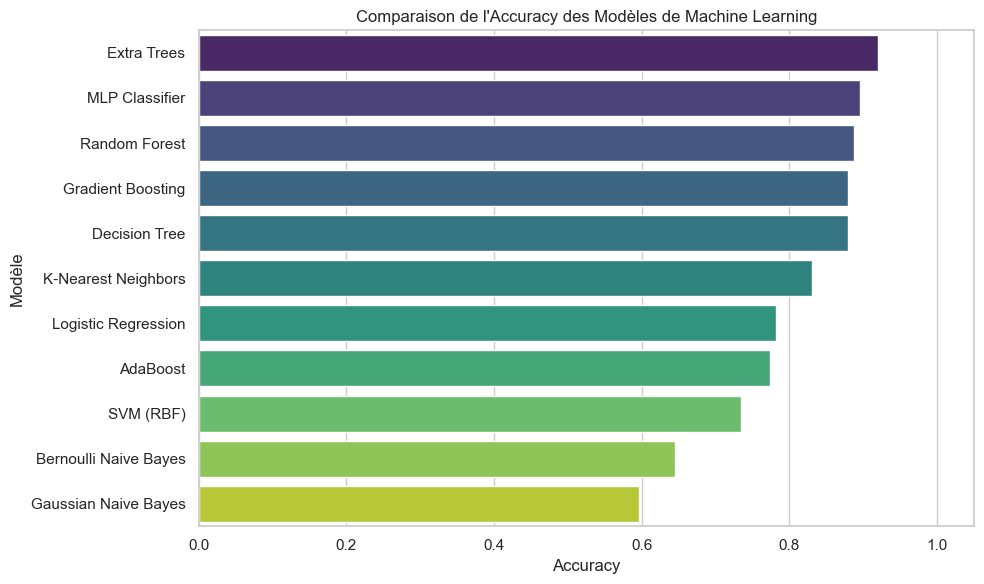

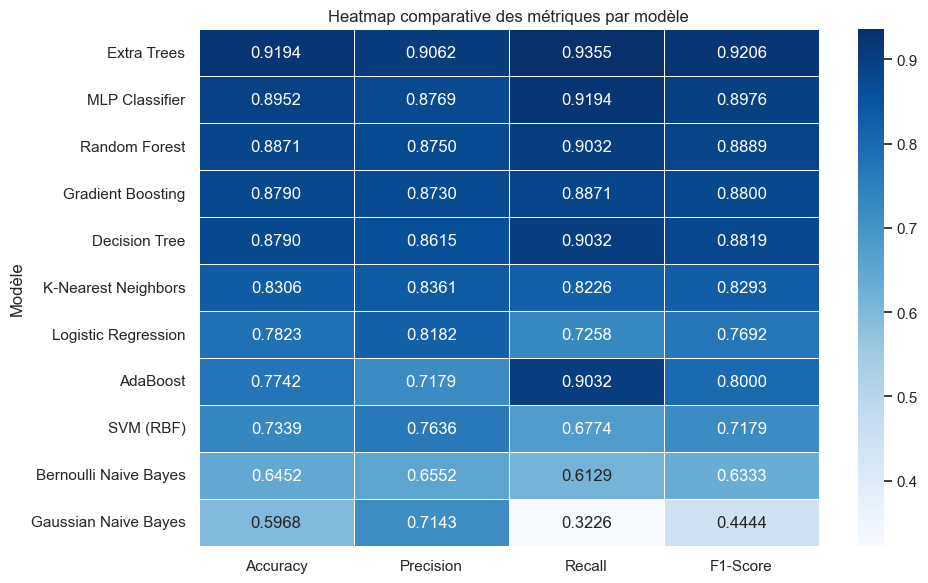

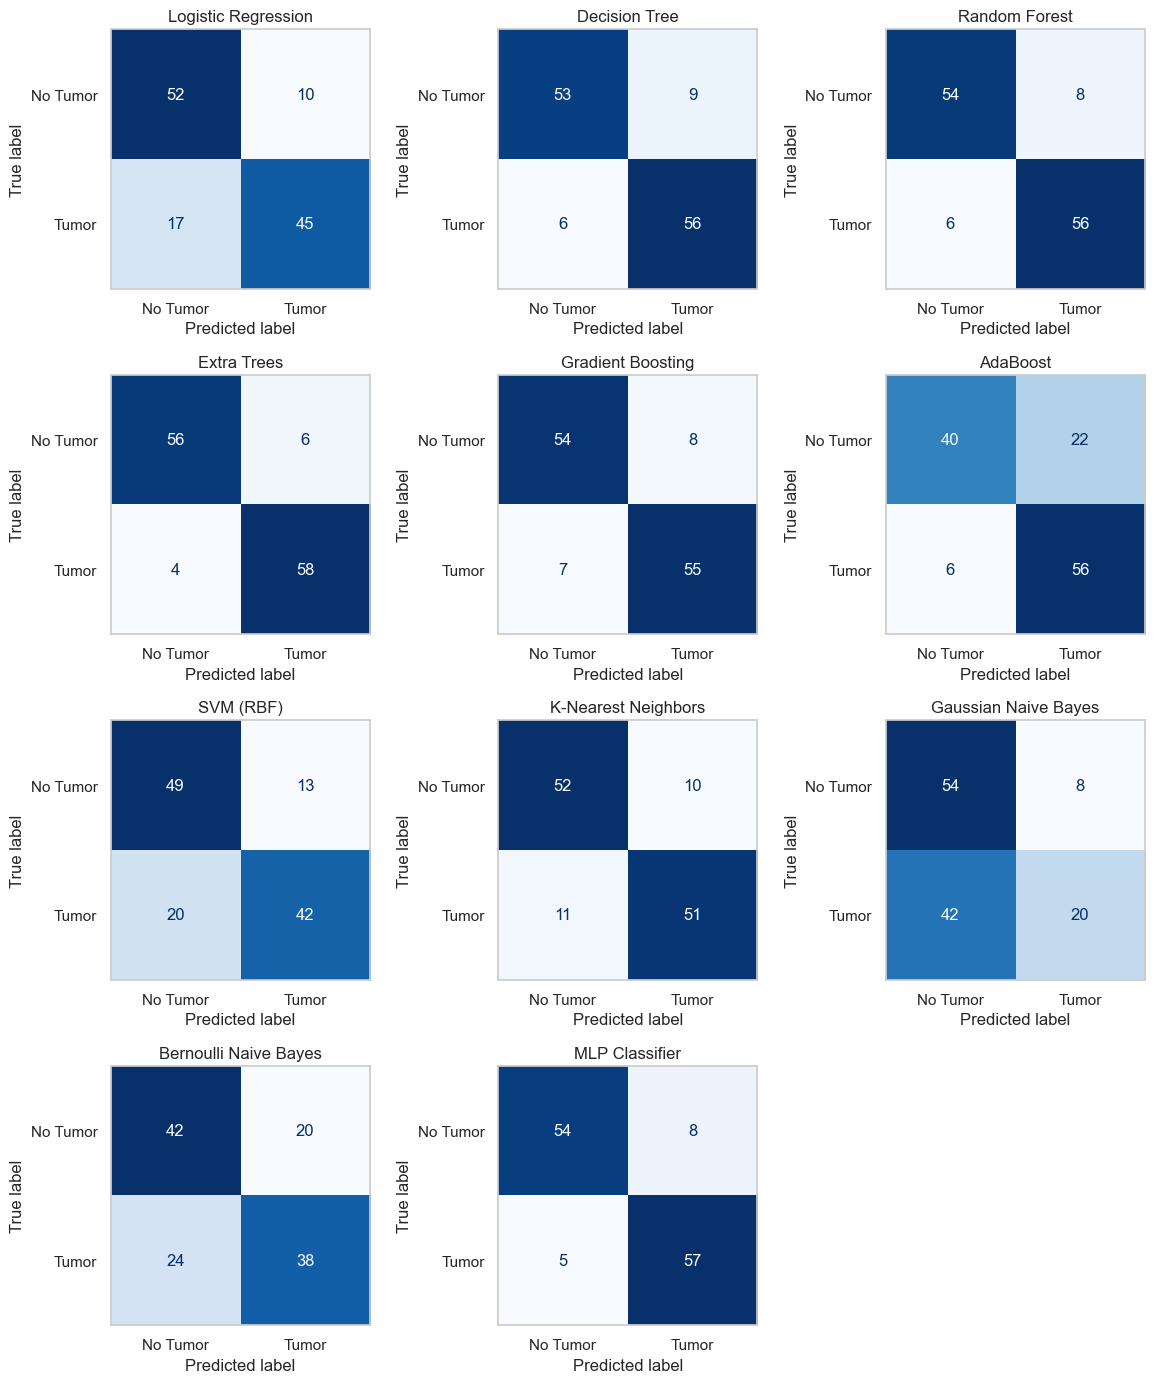

In [12]:
# 1. Bar plot of model accuracies
plot_model_comparison(results_df)

# 2. Heatmap of all metrics
plot_metrics_heatmap(results_df)

# 3. Grid of confusion matrices for error analysis
plot_confusion_matrices(confusion_matrices)

# Analyse des performances des modèles

## 1. Le meilleur modèle : Extra Trees Classifier

Le modèle le plus performant sur l’ensemble des métriques est **Extra Trees** (*Extremely Randomized Trees*) :

- **Accuracy (exactitude)** : environ **91,94 %**  
  Le taux de réussite global le plus élevé.

- **Précision** : environ **90,62 %**  
  Le modèle présente un faible taux de faux positifs. Lorsqu’il prédit une tumeur, il a raison dans plus de 90 % des cas.

- **Rappel (Recall)** : environ **93,55 %**  
  Cette métrique est particulièrement importante en imagerie médicale. Le modèle détecte plus de 93 % des véritables tumeurs, ce qui minimise le risque de manquer un diagnostic.

- **F1-Score** : environ **92,06 %**  
  Il représente un excellent compromis entre la précision et le rappel.

Le **MLP Classifier** (*perceptron multicouche*) et le **Random Forest** suivent de près, avec des scores d’accuracy respectifs d’environ **89,52 %** et **88,71 %**.

## 2. Raisons potentielles de ces performances

### Adéquation des modèles d’ensemble basés sur les arbres

Les caractéristiques tabulaires extraites des images, telles que les histogrammes de couleurs, les textures du Laplacien, les aires et les périmètres des contours, sont combinées à :

- une réduction de dimension par **PCA**, avec 30 composantes ;
- un rééquilibrage des classes grâce à **SMOTE**.

Ces transformations produisent un espace de données dense et non linéaire. Les algorithmes d’ensemble basés sur les arbres, comme **Extra Trees**, **Random Forest** et **Gradient Boosting**, sont particulièrement adaptés à ce type de données, car ils peuvent capturer des interactions complexes sans nécessiter d’hypothèses de linéarité.

### Pourquoi Extra Trees surpasse-t-il Random Forest ?

Bien que les deux modèles soient proches, **Extra Trees** introduit une randomisation supplémentaire lors du choix des seuils de coupure des nœuds.

Cette variabilité contrôlée permet de :

- réduire la variance globale du modèle ;
- améliorer la robustesse face au bruit potentiel ;
- limiter l’impact du bruit parfois introduit par le suréchantillonnage avec **SMOTE** ;
- réduire les risques de surapprentissage (*overfitting*).

### La force du MLP Classifier

Le **MLP Classifier** tire parti des 30 dimensions issues de la PCA pour modéliser des relations non linéaires sophistiquées grâce à ses couches cachées.

Cette capacité lui permet d’obtenir des performances proches de celles des meilleurs modèles basés sur les arbres.

## 3. Performances inférieures des modèles linéaires et probabilistes

Les modèles linéaires ou probabilistes, tels que le **SVM**, la **Régression Logistique** et le **Naive Bayes**, sont moins performants dans ce contexte.

### Gaussian Naive Bayes

Le **Gaussian Naive Bayes**, avec une accuracy d’environ **59,68 %**, repose sur deux hypothèses principales :

- les variables sont indépendantes les unes des autres ;
- les données suivent une distribution normale.

Ces hypothèses sont peu compatibles avec la structure des composantes issues de la PCA et avec les données générées par SMOTE.

### Régression Logistique et SVM

La **Régression Logistique** et le **SVM** tentent principalement de tracer des frontières de décision linéaires. Même avec un noyau RBF pour le SVM, la séparation des cas tumoraux et des cas sains reste insuffisante dans cet espace réduit.

La complexité des relations entre les caractéristiques extraites des images nécessite donc des modèles capables de capturer davantage d’interactions non linéaires.